In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

latent_dim = 100

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


In [4]:
!pip install pytorch-pretrained-biggan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.5 MB/s eta 0:00:00


In [5]:
import torch.nn as nn
from pytorch_pretrained_biggan import BigGAN

class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGANGenerator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

basic_generator = DCGANGenerator(latent_dim)
basic_generator.eval()
for param in basic_generator.parameters():
    param.requires_grad = False

advanced_generator = BigGAN.from_pretrained('biggan-deep-256')
advanced_generator.eval()
for param in advanced_generator.parameters():
    param.requires_grad = False

100%|██████████| 715/715 [00:00<00:00, 1942310.47B/s]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def interpolate_vectors(v1, v2, steps=10):
    ratios = np.linspace(0, 1, num=steps)
    vectors = [(1.0 - ratio) * v1 + ratio * v2 for ratio in ratios]
    return torch.stack(vectors)

z_samples = torch.randn(10, latent_dim, 1, 1)
generated_samples = basic_generator(z_samples)

v1 = torch.randn(1, latent_dim, 1, 1)
v2 = torch.randn(1, latent_dim, 1, 1)
interpolated_z = interpolate_vectors(v1, v2, steps=10)
interpolated_images = basic_generator(interpolated_z.squeeze(1))

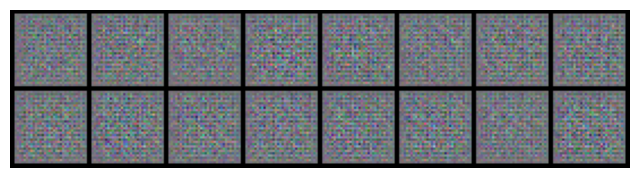

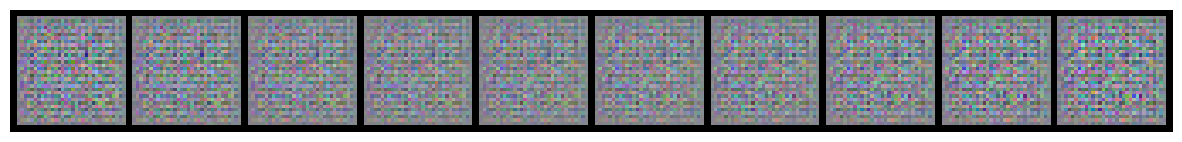

In [7]:
import torchvision.utils as vutils

z_art = torch.randn(16, latent_dim, 1, 1)
artistic_images = basic_generator(z_art)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(np.transpose(vutils.make_grid(artistic_images, padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()

plt.figure(figsize=(15, 3))
plt.axis("off")
plt.imshow(np.transpose(vutils.make_grid(interpolated_images, nrow=10, padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()